# Predicting Completion Risk in English Higher Education Providers

A binary classification study using student intake demographics to identify providers at risk of bottom-quartile completion rates, built on the Office for Students (OfS) Access and Participation dataset.


## Preamble: Imports and Reproducibility

All random seeds are fixed at 42 throughout this notebook. To verify full reproducibility, restart the kernel and run every cell from top to bottom. The dataset is loaded using a **relative path**, so `ofs_provider_outcomes.csv` must sit in the `data/` directory.

**Required libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `imbalanced-learn`, `xgboost`


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'sans-serif'
})


In [28]:
# Load dataset using relative path
df = pd.read_csv('../data/ofs_provider_outcomes.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(3)


Dataset shape: 312 rows x 33 columns


,provider,provider_name,continuation_rate,completion_rate,attainment_rate,progression_rate,continuation_rate_below_median,continuation_rate_bottom_quartile,completion_rate_below_median,completion_rate_bottom_quartile,...,pct_imd_q3,pct_imd_q4,pct_polar_q1,pct_polar_q2,pct_polar_q3,pct_polar_q4,pct_tundra_q1,pct_tundra_q2,pct_tundra_q3,pct_tundra_q4
0,10042570,AAP Education Limited,91.1,83.1,79.4,76.7,False,False,False,False,...,21.9,17.1,7.3,8.7,17.2,28.5,6.6,10.7,13.3,23.9
1,10067853,ACM Guildford Limited,82.2,77.1,73.5,69.9,True,False,True,False,...,20.3,21.0,11.3,14.1,19.6,23.9,12.0,15.7,19.6,23.6
2,10000055,Abingdon and Witney College,68.2,72.2,NaN,NaN,True,True,True,True,...,11.9,32.4,13.8,13.8,13.8,17.2,NaN,27.6,27.6,24.1


## 1. Context

This project uses data from the **Office for Students (OfS)** Access and Participation Data
Dashboard. The OfS regulates higher education in England and holds providers accountable for
closing outcome gaps between under-represented groups and the wider student population.
Providers submit legally binding Access and Participation Plans, and this dataset is part of
how the OfS tracks whether those commitments actually lead to improvements.

Each row is a single provider, with statistics rolled up across four reporting years to smooth
out year-to-year noise (including COVID disruption). The 312 providers cover the full spread
of English HE: research-intensive universities, post-1992 institutions, FE colleges delivering
higher education, and specialist providers like conservatoires and art schools.

The columns fall into two groups. Outcome variables (continuation, completion, attainment,
progression rates) measure what happens to students after they enrol. Composition variables
describe who attends each provider: age, disability, sex, ethnicity, and three area-based
indices for deprivation and participation (IMD, POLAR4, TUNDRA).

Looking at the data, attainment rate is missing for 62 providers (19.9%) and progression
for 13 (4.2%), but completion rate is only missing for 6 (1.9%). That makes completion rate
the most practical target variable since it gives us 306 usable rows compared to just 250 for
attainment. The missing-value chart below shows this clearly.

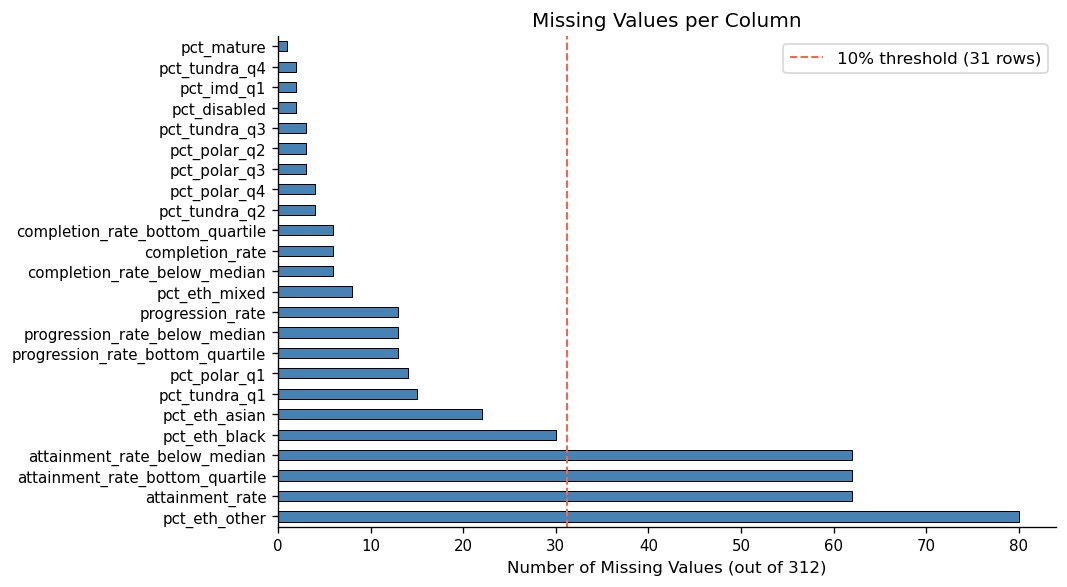

pct_eth_other                       80
attainment_rate                     62
attainment_rate_bottom_quartile     62
attainment_rate_below_median        62
pct_eth_black                       30
pct_eth_asian                       22
pct_tundra_q1                       15
pct_polar_q1                        14
progression_rate_bottom_quartile    13
progression_rate_below_median       13
progression_rate                    13
pct_eth_mixed                        8
completion_rate_below_median         6
completion_rate                      6
completion_rate_bottom_quartile      6
pct_tundra_q2                        4
pct_polar_q4                         4
pct_polar_q3                         3
pct_polar_q2                         3
pct_tundra_q3                        3
pct_disabled                         2
pct_imd_q1                           2
pct_tundra_q4                        2
pct_mature                           1


In [29]:
# Visualise missing values across all columns
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(9, 5))
missing.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.6)
ax.set_xlabel('Number of Missing Values (out of 312)')
ax.set_title('Missing Values per Column')
ax.axvline(312 * 0.1, color='tomato', linestyle='--', linewidth=1.2,
           label='10% threshold (31 rows)')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(missing.to_string())


The chart confirms what the `.info()` output suggested. `pct_eth_other` has the worst
coverage at 80 missing values (25.6%), followed by the three attainment columns at 62 each.
`pct_eth_black` is missing for 30 providers (9.6%). The completion rate columns sit near
the bottom with only 6 gaps. That 1.9% vs 19.9% difference is why completion rate was
chosen as the target. Only 4 columns exceed the 10% threshold (red dashed line), all relating
to attainment or ethnicity.

## 2. Problem Statement

The central question is:

> *Can a provider's student intake composition predict whether it falls into the bottom
> quartile for completion rate?*

Completion rate measures the share of students who actually finish their programme within
the expected timeframe. The OfS treats this as a core accountability metric; providers
with persistently low completion face regulatory scrutiny and potential sanctions.
Identifying the worst-performing 25% creates a clear-cut classification boundary that is
directly useful for deciding where to target intervention resources.

This is a binary classification task. The continuous completion rate is split at its
25th percentile: providers below are labelled y=1 (bottom quartile, n=77) and those above
are y=0 (n=229), giving a 25.2% positive rate.

Each provider is described by 19 student composition percentages:

| Group | Features |
|---|---|
| Age | `pct_mature` (share aged 21+ at entry) |
| Disability | `pct_disabled` |
| Sex | `pct_female` |
| Ethnicity (4) | `pct_eth_asian`, `pct_eth_black`, `pct_eth_mixed`, `pct_eth_other` |
| IMD (Q1 to Q4) | `pct_imd_q1` through `pct_imd_q4` (Q1 = most deprived 20%) |
| POLAR4 (Q1 to Q4) | `pct_polar_q1` through `pct_polar_q4` (Q1 = lowest HE participation) |
| TUNDRA (Q1 to Q4) | `pct_tundra_q1` through `pct_tundra_q4` |

Reference categories (white ethnicity, IMD Q5, POLAR Q5, TUNDRA Q5) are left out to avoid
multicollinearity since they can be derived from the others (each group sums to roughly 100%).

The target variable y is in {0, 1}, where y=1 means the provider is in the lowest 25% by completion rate.

If intake composition alone can reliably flag low-completion providers, it would mean that
completion gaps are largely baked into who attends each institution rather than being
random. Features like `pct_imd_q1` and `pct_mature` would become early-warning signals
that the OfS could use when reviewing Access and Participation Plans. The ethical side of
this is discussed in Section 3.

In [30]:
# Feature and target definition
FEATURES = [
    'pct_mature', 'pct_disabled', 'pct_female',
    'pct_eth_asian', 'pct_eth_black', 'pct_eth_mixed', 'pct_eth_other',
    'pct_imd_q1', 'pct_imd_q2', 'pct_imd_q3', 'pct_imd_q4',
    'pct_polar_q1', 'pct_polar_q2', 'pct_polar_q3', 'pct_polar_q4',
    'pct_tundra_q1', 'pct_tundra_q2', 'pct_tundra_q3', 'pct_tundra_q4'
]
TARGET = 'completion_rate_bottom_quartile'

# Drop rows where the target is missing; convert to integer
df_model = df[FEATURES + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].map(lambda x: 1 if str(x).strip() == 'True' else 0)

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Modelling dataset : {X.shape[0]} rows x {X.shape[1]} features')
print(f'Target distribution:\n{y.value_counts().to_string()}')
print(f'Positive rate (bottom quartile): {y.mean():.1%}')


Modelling dataset : 306 rows x 19 features
Target distribution:
completion_rate_bottom_quartile
0    229
1     77
Positive rate (bottom quartile): 25.2%


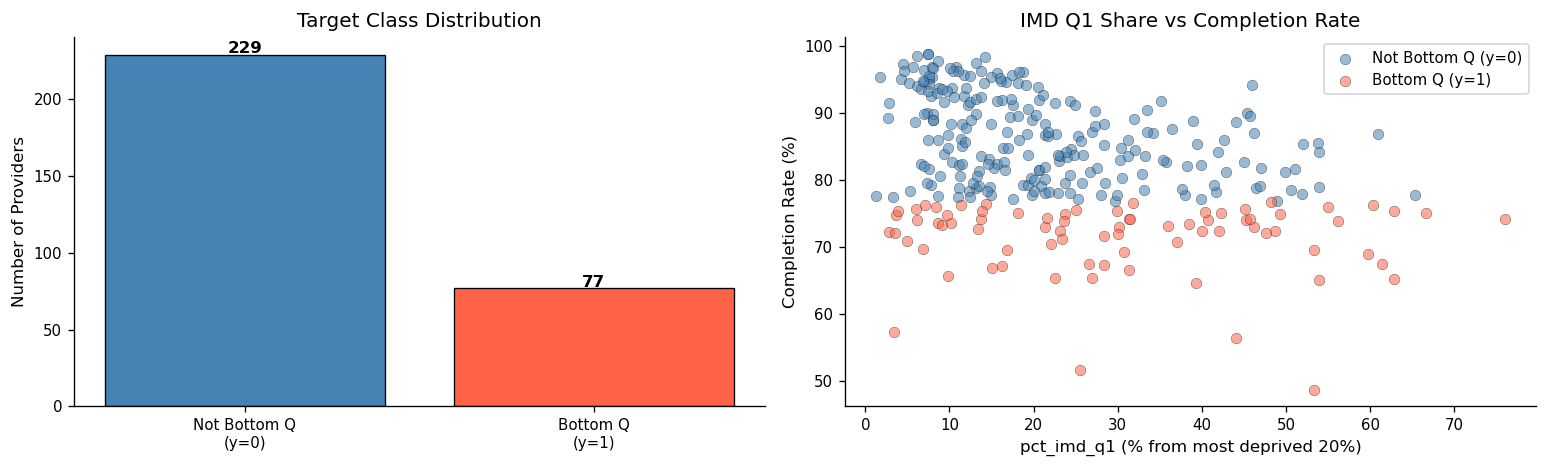

In [31]:
# EDA: class distribution + IMD Q1 vs completion rate scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: class counts
ax = axes[0]
counts = y.value_counts().sort_index()
bars = ax.bar(
    ['Not Bottom Q\n(y=0)', 'Bottom Q\n(y=1)'],
    [counts[0], counts[1]],
    color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')
ax.set_ylabel('Number of Providers')
ax.set_title('Target Class Distribution')
sns.despine(ax=ax)

# Right: pct_imd_q1 vs completion_rate, coloured by target
ax2 = axes[1]
df_scatter = df_model.copy()
df_scatter['completion_rate'] = df.loc[df_model.index, 'completion_rate'].values
colour_map = {0: 'steelblue', 1: 'tomato'}
for cls, grp in df_scatter.groupby(TARGET):
    label = 'Bottom Q (y=1)' if cls == 1 else 'Not Bottom Q (y=0)'
    ax2.scatter(grp['pct_imd_q1'], grp['completion_rate'],
                c=colour_map[cls], alpha=0.55, edgecolors='black',
                linewidths=0.3, s=40, label=label)
ax2.set_xlabel('pct_imd_q1 (% from most deprived 20%)')
ax2.set_ylabel('Completion Rate (%)')
ax2.set_title('IMD Q1 Share vs Completion Rate')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig('../figures/fig_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


The left panel shows 229 providers above the bottom quartile and 77 within it, roughly
a 3:1 split. This imbalance is important: a model that just predicts "not bottom quartile"
for everyone would get 74.8% accuracy while being completely useless, which is why we need
SMOTE oversampling and macro F1 as the scoring metric.

The scatter plot on the right gives a first look at the relationship between deprivation
and completion. Bottom-quartile providers (red dots) tend to cluster in the lower-right:
they have higher `pct_imd_q1` (mean 30.2% vs 20.7%) and lower completion rates (mean
71.4% vs 86.6%). But there is a lot of overlap in the middle, so `pct_imd_q1` on its
own is clearly not enough, and the full 19-feature vector is needed.

## 3. Methodology

### 3.1 Feature Representations

Each provider is treated as an independent observation. Aggregating across four years is
assumed to give stable structural characteristics rather than a snapshot of any single year.
It is worth flagging upfront that the feature vector includes proxies for protected
characteristics, particularly `pct_eth_black`, `pct_eth_asian`, and the deprivation
quintile variables. A model that flags institutions with high proportions of students from
deprived backgrounds as "at risk" could easily be misread as blaming those institutions,
when the real story is about systemic inequalities affecting their students. So the results
here should be treated as descriptive of structural patterns, not as a basis for punishment.

Missing values range from near zero to about 26% depending on the column. Median
imputation using training-set statistics is applied, and those medians are then reused on
the test set. Median was picked over mean because several ethnicity columns are heavily
right-skewed (lots of zeros). All imputation happens inside the scikit-learn pipeline so
that test-set values never leak into training.

Class imbalance is a real concern with only 25% positives. To deal with this, SMOTE is
applied within the training pipeline after imputation, generating synthetic minority-class
examples in feature space. Combined with `class_weight='balanced'` where the model supports
it. SMOTE is only applied inside the CV folds, never on the held-out validation or test
portions, to avoid inflating performance estimates.

All 19 features are already continuous percentages, so there is nothing to encode.
Logistic Regression and SVM need standardisation (their penalties are scale-sensitive),
so those pipelines include a `StandardScaler` step. The tree-based models do not need it.

A `SelectKBest` step with ANOVA F-statistic is added to the LR pipeline as a tunable
parameter. The idea is to let the grid search figure out whether dropping some of the
noisier features actually helps, since the boxplots showed that several features
(e.g., `pct_disabled`, `pct_eth_black`) have very small median differences between
classes.

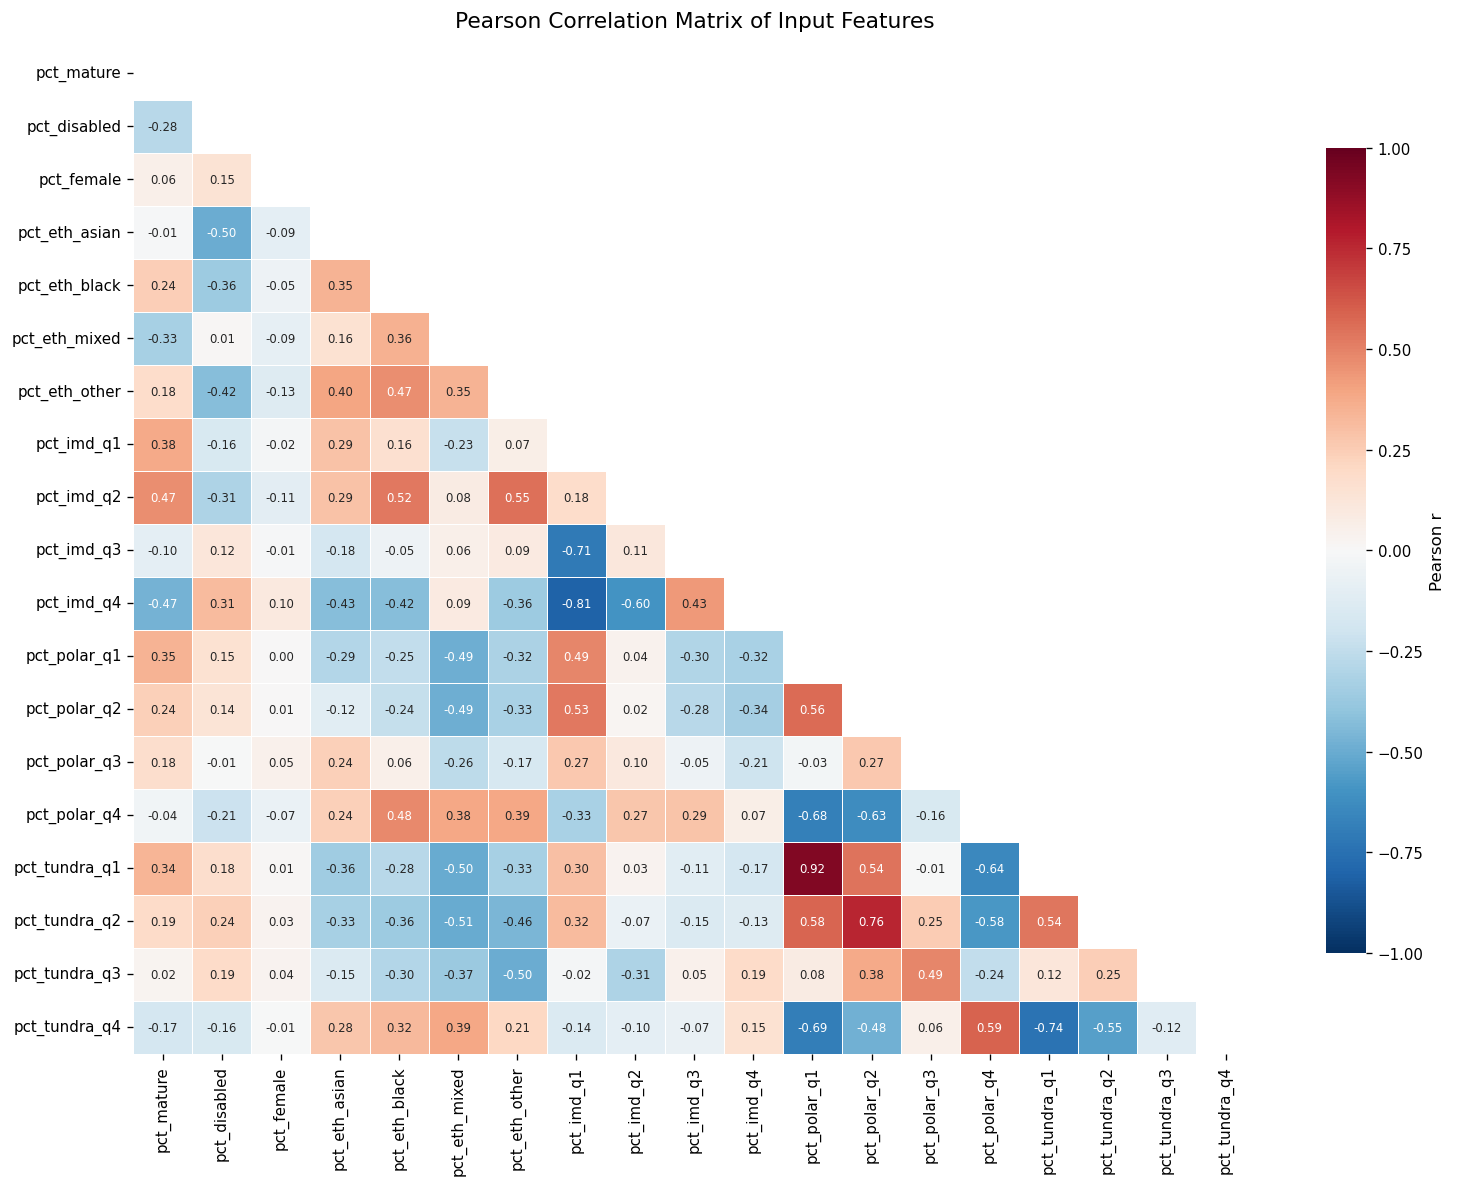

In [32]:
# Pearson correlation matrix of all input features
fig, ax = plt.subplots(figsize=(13, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={'size': 7}, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title('Pearson Correlation Matrix of Input Features', pad=12, fontsize=13)
plt.tight_layout()
plt.savefig('../figures/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Three blocks of strong within-group correlation stand out immediately. The tightest pair
is `pct_polar_q1` and `pct_tundra_q1` at r=0.923, which makes sense since POLAR and TUNDRA
both measure low HE participation using overlapping methodologies. Within the IMD block,
`pct_imd_q1` and `pct_imd_q4` are strongly negatively correlated (r=-0.809); providers
that draw heavily from the most deprived areas necessarily have fewer students from the
least deprived quintile. The POLAR and TUNDRA blocks show the same pattern.

This collinearity has two practical consequences. First, it makes Logistic Regression
coefficients unreliable without strong regularisation (which is why L2 and SelectKBest
are in the pipeline). Second, PCA could reduce redundancy, but it was rejected because
we need to interpret features by name for the policy conclusions to be meaningful.

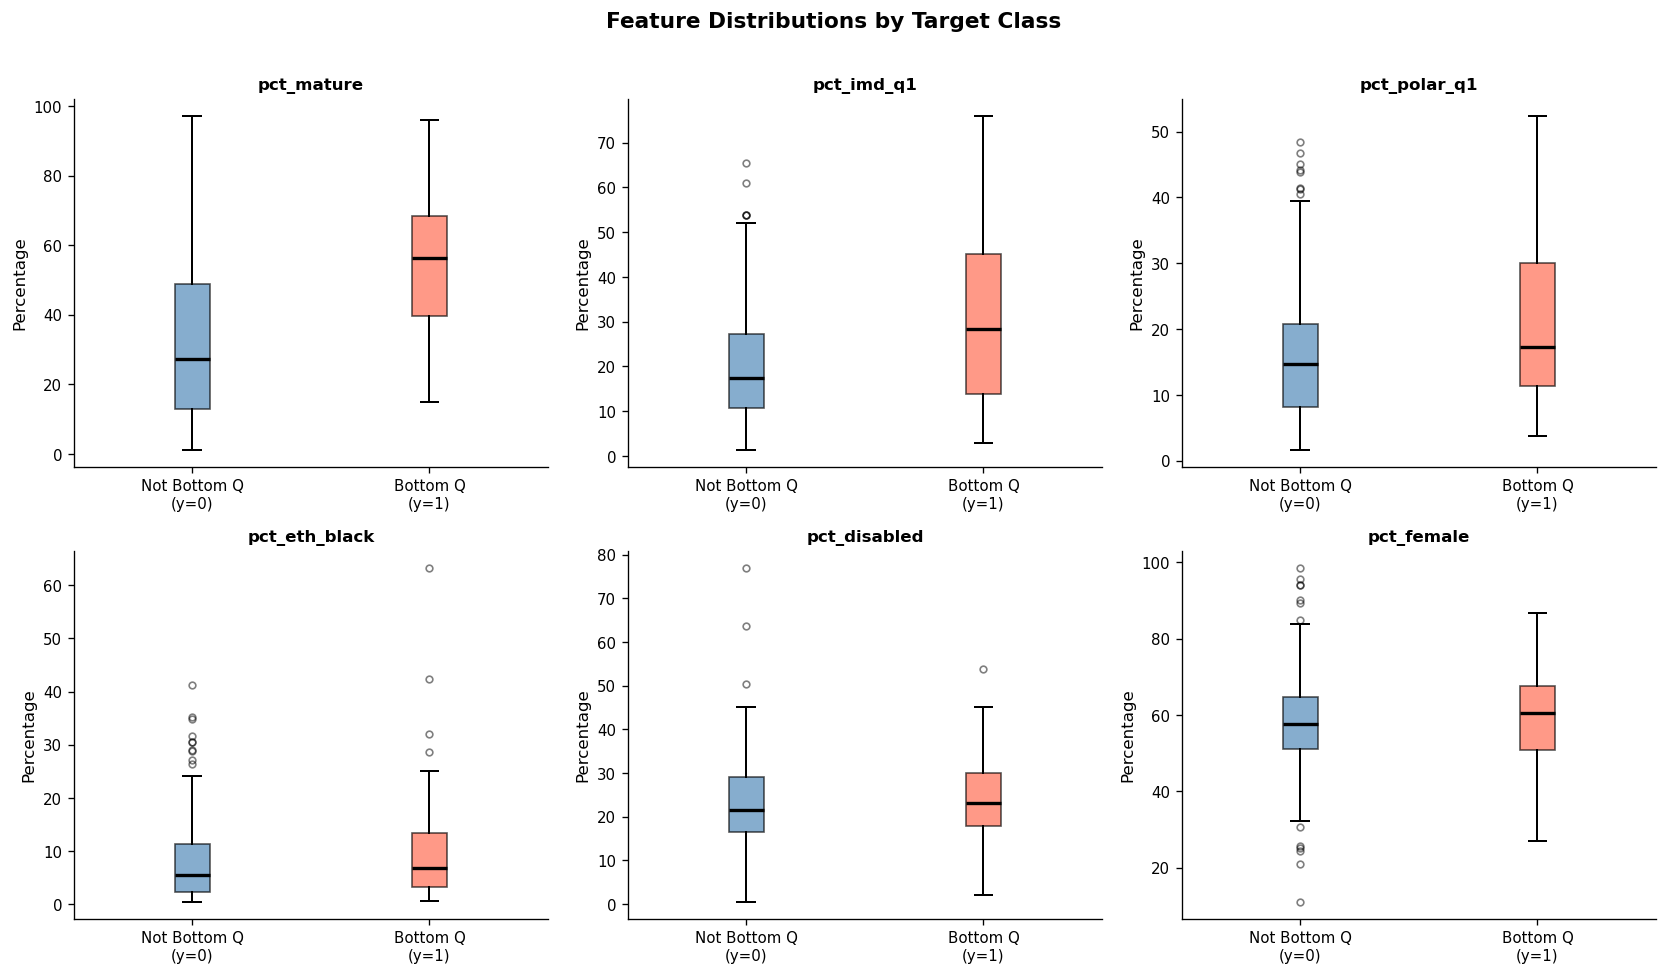

In [33]:
# Boxplots for key features split by target class
selected_feats = [
    'pct_mature', 'pct_imd_q1', 'pct_polar_q1',
    'pct_eth_black', 'pct_disabled', 'pct_female'
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
bp_colours = ['steelblue', 'tomato']

for i, feat in enumerate(selected_feats):
    groups = [df_model.loc[y == c, feat].dropna().values for c in [0, 1]]
    bp = axes[i].boxplot(
        groups,
        labels=['Not Bottom Q\n(y=0)', 'Bottom Q\n(y=1)'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    for patch, col in zip(bp['boxes'], bp_colours):
        patch.set_facecolor(col)
        patch.set_alpha(0.65)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    sns.despine(ax=axes[i])

plt.suptitle('Feature Distributions by Target Class', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


The standout feature here is `pct_mature`. The median for bottom-quartile providers is
56.2% compared to 27.2% for the rest, a gap of 29 percentage points, and the
interquartile ranges barely overlap. No other feature comes close to that level of
separation. `pct_imd_q1` shows a smaller but real shift (+11 points), though with wider
spread. The other four features (`pct_polar_q1` at +2.7, `pct_female` +2.9,
`pct_disabled` +1.6, `pct_eth_black` +1.4) are not very informative on their own, though
they could still help in combination when fed into the tree-based models.

### 3.2 Model Design and Training Regime

Five classifiers were selected, each chosen to test a different modelling assumption:

1. **Logistic Regression (LR)** with L2 regularisation, serving as the interpretable linear
   baseline. Its coefficients show how each feature relates to completion risk. `SelectKBest`
   is included because the boxplots showed many features have negligible standalone separation.

2. **Random Forest (RF)**: captures non-linear interactions (the scatter plot shows
   substantial overlap where a linear boundary would struggle). Bagging helps with variance
   on a small dataset.

3. **Gradient Boosting (GB)**: sequential shallow trees that correct each other's errors.
   Generally achieves lower bias than RF on structured tabular data.

4. **XGBoost (XGB)**: like GB but adds L1/L2 regularisation on leaf weights, which acts
   as built-in feature selection. Relevant here because the 19 features are quite collinear.

5. **SVM with RBF kernel**: tests whether a kernel-based approach finds decision boundaries
   the tree models miss. SVMs tend to struggle with collinear data, so this partly serves
   as a sanity check.

All models minimise binary cross-entropy during training. For evaluation, the primary
metric is **macro F1-score**, which treats both classes equally. This matters because a
majority-class classifier would hit 74.8% accuracy while catching zero at-risk providers.
ROC-AUC is also reported as a threshold-independent measure. `class_weight='balanced'` is
set for LR and RF.

## 4. Experimental Set-up

We have 306 usable rows after dropping providers with missing completion data. A stratified
80/20 split gives 244 training and 62 test samples. The 20% test set provides roughly 16
positive cases, just about enough for stable per-class metrics. Making the test set any
larger would starve the training set, which is already small.

Tuning uses 5-fold stratified CV on the training set, scored by macro F1 via `GridSearchCV`.
Five folds felt like the right balance: 3 folds would leave only ~16 positive examples per
validation fold, and 10 folds would not add much at this sample size. SMOTE is applied
inside each pipeline after imputation at a 1:1 ratio. Because SMOTE only runs on the
training folds and never on the validation portion, the CV scores should not be inflated.

**Search grids:**

| Model | Hyperparameter | Grid |
|---|---|---|
| LR | C, selector k | [0.001, 0.01, 0.1, 1, 10, 100] (log-spaced), [10, 15, 19] |
| RF | n_estimators, max_depth, min_split | [100, 200, 300], [3, 5, 7, 10], [5, 10, 15] |
| GB | n_estimators, max_depth, learning_rate | [100, 200, 300], [2, 3, 4], [0.01, 0.05, 0.1] |
| XGB | n_estimators, max_depth, learning_rate, reg_alpha | [100, 200, 300], [3, 4, 5, 6], [0.01, 0.05, 0.1], [0, 0.1, 1.0] |
| SVM | C, gamma | [0.1, 1, 10, 100], [scale, 0.01, 0.1] |

The ranges span from strong regularisation to nearly unregularised, letting the search find
the right bias-variance trade-off for each model.

In [34]:
# Stratified train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Train : {X_train.shape[0]} samples | positive rate: {y_train.mean():.1%}')
print(f'Test  : {X_test.shape[0]} samples  | positive rate: {y_test.mean():.1%}')

# 5-fold stratified CV for hyperparameter tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


Train : 244 samples | positive rate: 25.0%
Test  : 62 samples  | positive rate: 25.8%


In [35]:
# Model pipelines with SMOTE oversampling and optional feature selection

# Logistic Regression: impute -> SMOTE -> select features -> scale -> classify
pipe_lr = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('smote',    SMOTE(random_state=RANDOM_SEED)),
    ('selector', SelectKBest(f_classif)),
    ('scaler',   StandardScaler()),
    ('clf',      LogisticRegression(penalty='l2', class_weight='balanced',
                                     max_iter=2000, random_state=RANDOM_SEED))
])
param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'selector__k': [10, 15, 19]
}

# Random Forest: impute -> SMOTE -> classify
pipe_rf = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=RANDOM_SEED)),
    ('clf',     RandomForestClassifier(class_weight='balanced',
                                        random_state=RANDOM_SEED))
])
param_grid_rf = {
    'clf__n_estimators':     [100, 200, 300],
    'clf__max_depth':        [3, 5, 7, 10],
    'clf__min_samples_split': [5, 10, 15]
}

# Gradient Boosting: impute -> SMOTE -> classify
pipe_gb = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=RANDOM_SEED)),
    ('clf',     GradientBoostingClassifier(random_state=RANDOM_SEED))
])
param_grid_gb = {
    'clf__n_estimators':  [100, 200, 300],
    'clf__max_depth':     [2, 3, 4],
    'clf__learning_rate': [0.01, 0.05, 0.1]
}

# XGBoost: impute -> SMOTE -> classify
pipe_xgb = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=RANDOM_SEED)),
    ('clf',     XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                               random_state=RANDOM_SEED))
])
param_grid_xgb = {
    'clf__n_estimators':  [100, 200, 300],
    'clf__max_depth':     [3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__reg_alpha':     [0, 0.1, 1.0]
}

# SVM: impute -> SMOTE -> scale -> classify (probability=True for ROC-AUC)
pipe_svm = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=RANDOM_SEED)),
    ('scaler',  StandardScaler()),
    ('clf',     SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=RANDOM_SEED))
])
param_grid_svm = {
    'clf__C':     [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 0.01, 0.1]
}

print('All 5 model pipelines defined (with SMOTE oversampling).')


All 5 model pipelines defined (with SMOTE oversampling).


## 5. Evaluation

### 5.1 Hyperparameter Tuning Results


In [36]:
# Grid search for all five models
models_to_tune = [
    ('Logistic Regression', pipe_lr, param_grid_lr),
    ('Random Forest',       pipe_rf, param_grid_rf),
    ('Gradient Boosting',   pipe_gb, param_grid_gb),
    ('XGBoost',             pipe_xgb, param_grid_xgb),
    ('SVM (RBF)',           pipe_svm, param_grid_svm),
]

grid_searches = {}
for name, pipe, params in models_to_tune:
    print(f'Tuning {name} ...')
    gs = GridSearchCV(pipe, params, cv=cv, scoring='f1_macro',
                      n_jobs=-1, return_train_score=True)
    gs.fit(X_train, y_train)
    grid_searches[name] = gs
    print(f'  Best CV F1-macro: {gs.best_score_:.4f}  |  {gs.best_params_}')

print('\nTuning complete for all 5 models.')


Tuning Logistic Regression ...
  Best CV F1-macro: 0.6244  |  {'clf__C': 0.01, 'selector__k': 15}
Tuning Random Forest ...
  Best CV F1-macro: 0.6887  |  {'clf__max_depth': 7, 'clf__min_samples_split': 15, 'clf__n_estimators': 100}
Tuning Gradient Boosting ...
  Best CV F1-macro: 0.7047  |  {'clf__learning_rate': 0.01, 'clf__max_depth': 4, 'clf__n_estimators': 300}
Tuning XGBoost ...
  Best CV F1-macro: 0.7056  |  {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 100, 'clf__reg_alpha': 1.0}
Tuning SVM (RBF) ...
  Best CV F1-macro: 0.6111  |  {'clf__C': 1, 'clf__gamma': 0.01}

Tuning complete for all 5 models.


In [37]:
# Summary table of best CV results
rows = []
for name, gs in grid_searches.items():
    # Format parameters cleanly (remove 'clf__' prefix for readability)
    params_clean = {k.replace('clf__', '').replace('selector__', ''): v
                    for k, v in gs.best_params_.items()}
    params_str = ', '.join(f'{k}={v}' for k, v in params_clean.items())
    rows.append({
        'Model':            name,
        'Best CV F1-macro': round(gs.best_score_, 4),
        'Best Parameters':  params_str
    })

tuning_summary = pd.DataFrame(rows).sort_values('Best CV F1-macro', ascending=False).reset_index(drop=True)

# Ensure full column width is displayed
pd.set_option('display.max_colwidth', None)
tuning_summary


,Model,Best CV F1-macro,Best Parameters
0,XGBoost,0.7056,"learning_rate=0.05, max_depth=4, n_estimators=100, reg_alpha=1.0"
1,Gradient Boosting,0.7047,"learning_rate=0.01, max_depth=4, n_estimators=300"
2,Random Forest,0.6887,"max_depth=7, min_samples_split=15, n_estimators=100"
3,Logistic Regression,0.6244,"C=0.01, k=15"
4,SVM (RBF),0.6111,"C=1, gamma=0.01"


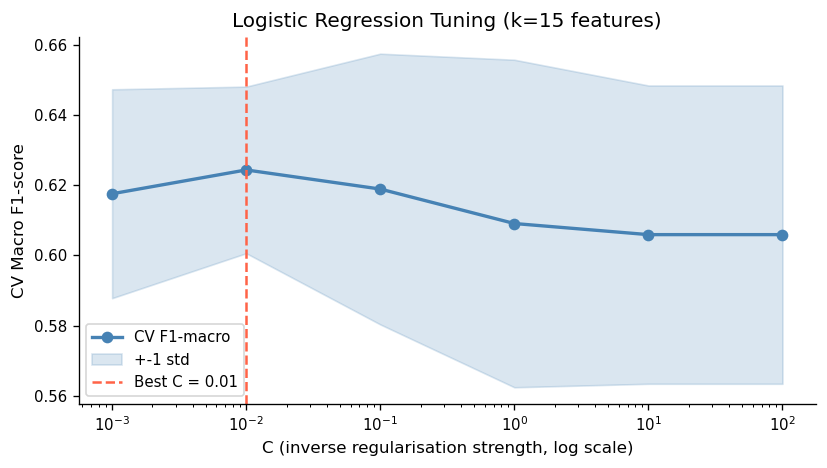

In [38]:
# LR: CV F1-macro vs regularisation strength C (at best k)
gs_lr = grid_searches['Logistic Regression']
lr_res = pd.DataFrame(gs_lr.cv_results_)
best_k = gs_lr.best_params_['selector__k']
lr_sub = lr_res[lr_res['param_selector__k'] == best_k]
c_vals = [p['clf__C'] for _, p in lr_sub['params'].items()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(c_vals, lr_sub['mean_test_score'].values,
            marker='o', color='steelblue', linewidth=2, label='CV F1-macro')
ax.fill_between(
    c_vals,
    lr_sub['mean_test_score'].values - lr_sub['std_test_score'].values,
    lr_sub['mean_test_score'].values + lr_sub['std_test_score'].values,
    alpha=0.2, color='steelblue', label='+-1 std'
)
ax.axvline(gs_lr.best_params_['clf__C'], color='tomato', linestyle='--',
           linewidth=1.5, label=f"Best C = {gs_lr.best_params_['clf__C']}")
ax.set_xlabel('C (inverse regularisation strength, log scale)')
ax.set_ylabel('CV Macro F1-score')
ax.set_title(f'Logistic Regression Tuning (k={best_k} features)')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_lr_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


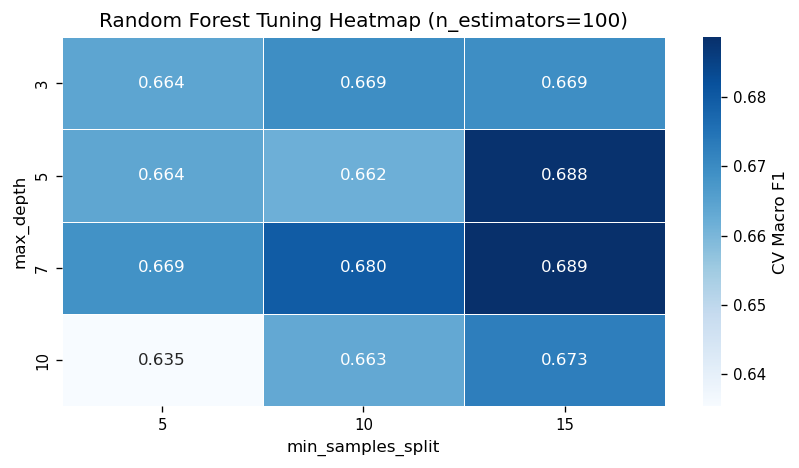

In [39]:
# Random Forest: F1 heatmap
gs_rf = grid_searches['Random Forest']
rf_res = pd.DataFrame(gs_rf.cv_results_)
best_n_rf = gs_rf.best_params_['clf__n_estimators']
subset_rf = rf_res[rf_res['param_clf__n_estimators'] == best_n_rf].copy()

pivot_rf = subset_rf.pivot_table(
    index='param_clf__max_depth',
    columns='param_clf__min_samples_split',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_rf, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            cbar_kws={'label': 'CV Macro F1'}, linewidths=0.5)
ax.set_title(f'Random Forest Tuning Heatmap (n_estimators={best_n_rf})')
ax.set_xlabel('min_samples_split')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('../figures/fig_rf_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


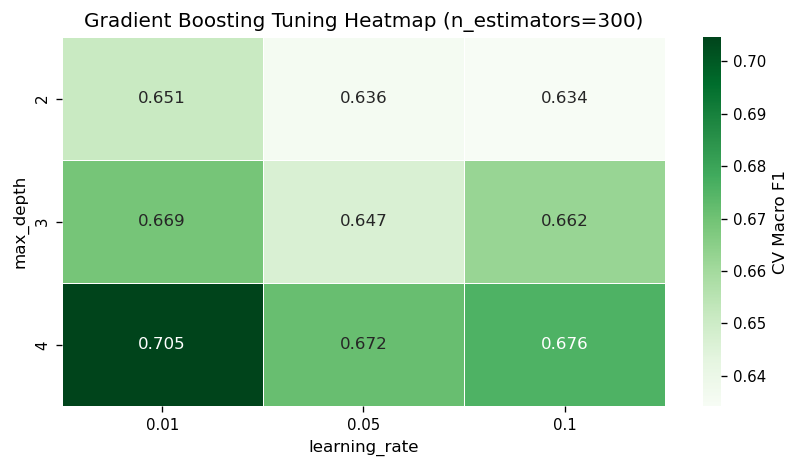

In [40]:
# Gradient Boosting: F1 heatmap
gs_gb = grid_searches['Gradient Boosting']
gb_res = pd.DataFrame(gs_gb.cv_results_)
best_n_gb = gs_gb.best_params_['clf__n_estimators']
subset_gb = gb_res[gb_res['param_clf__n_estimators'] == best_n_gb].copy()

pivot_gb = subset_gb.pivot_table(
    index='param_clf__max_depth',
    columns='param_clf__learning_rate',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_gb, annot=True, fmt='.3f', cmap='Greens', ax=ax,
            cbar_kws={'label': 'CV Macro F1'}, linewidths=0.5)
ax.set_title(f'Gradient Boosting Tuning Heatmap (n_estimators={best_n_gb})')
ax.set_xlabel('learning_rate')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('../figures/fig_gb_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


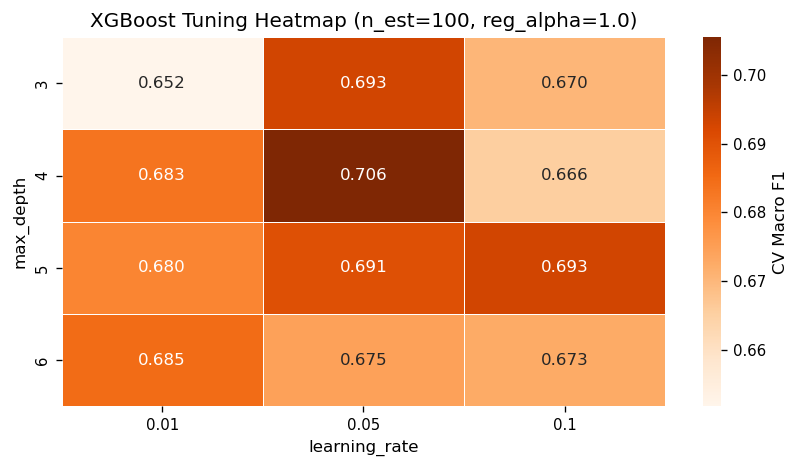

In [41]:
# XGBoost: F1 heatmap (max_depth x learning_rate at best n_estimators and reg_alpha)
gs_xgb = grid_searches['XGBoost']
xgb_res = pd.DataFrame(gs_xgb.cv_results_)
best_n_xgb = gs_xgb.best_params_['clf__n_estimators']
best_a_xgb = gs_xgb.best_params_['clf__reg_alpha']
subset_xgb = xgb_res[
    (xgb_res['param_clf__n_estimators'] == best_n_xgb) &
    (xgb_res['param_clf__reg_alpha'] == best_a_xgb)
].copy()

pivot_xgb = subset_xgb.pivot_table(
    index='param_clf__max_depth',
    columns='param_clf__learning_rate',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_xgb, annot=True, fmt='.3f', cmap='Oranges', ax=ax,
            cbar_kws={'label': 'CV Macro F1'}, linewidths=0.5)
ax.set_title(f'XGBoost Tuning Heatmap (n_est={best_n_xgb}, reg_alpha={best_a_xgb})')
ax.set_xlabel('learning_rate')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('../figures/fig_xgb_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


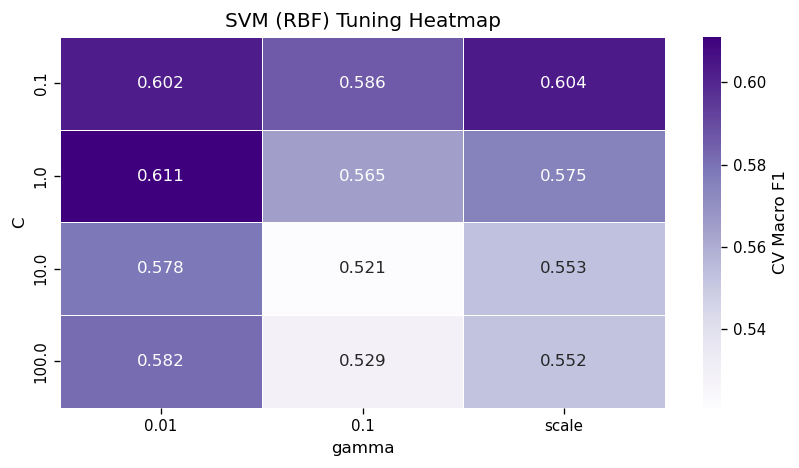

In [42]:
# SVM (RBF): F1 heatmap (C x gamma)
gs_svm = grid_searches['SVM (RBF)']
svm_res = pd.DataFrame(gs_svm.cv_results_)

# Convert 'scale' gamma to string for consistent pivot
svm_res['param_clf__gamma'] = svm_res['param_clf__gamma'].astype(str)

pivot_svm = svm_res.pivot_table(
    index='param_clf__C',
    columns='param_clf__gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_svm, annot=True, fmt='.3f', cmap='Purples', ax=ax,
            cbar_kws={'label': 'CV Macro F1'}, linewidths=0.5)
ax.set_title('SVM (RBF) Tuning Heatmap')
ax.set_xlabel('gamma')
ax.set_ylabel('C')
plt.tight_layout()
plt.savefig('../figures/fig_svm_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


#### Tuning Discussion

For Logistic Regression, CV F1 peaks at C=0.01 with 15 features, giving 0.6244. Very low
C (0.001) squashes all coefficients too far toward zero; very high C (10, 100) lets the
model overfit on the collinear IMD and POLAR features. Dropping 4 of the 19 features with
SelectKBest helped slightly, suggesting a few variables are adding noise rather than signal
for a linear model.

For Random Forest, at n_estimators=100, the best scores cluster around max_depth=7 and
min_samples_split=15 (F1=0.6887). Full-depth trees overfit on 244 rows, while depth=3 is
too shallow to pick up interactions between features like `pct_mature` and `pct_imd_q1`.
The high optimal min_samples_split tells us that preventing small, noisy leaf nodes really
matters at this sample size.

Gradient Boosting works best with a low learning rate (0.01) with 300 rounds (F1=0.7047).
Higher learning rates (0.1) overfit at all depths. Depth 4 outperforms depth 2, which
suggests the data has genuine interactions that need moderately deep trees.

XGBoost does best at depth=4 with learning_rate=0.05 (CV score 0.7056). The L1
penalty at reg_alpha=1.0 effectively zeros out the less useful features, acting as built-in
selection. This combination of moderate depth, moderate learning rate and strong L1 is
probably why XGBoost edges out standard GB by a tiny margin.

SVM (RBF) had the lowest CV F1 at 0.6111 (C=1, gamma=0.01). The collinear feature space does
not lend itself to the kind of margin structure that SVMs are built for, which is roughly
what was expected.

### 5.2 Final Model Evaluation


In [43]:
# Evaluate all five best models on held-out test set
all_models = {name: gs.best_estimator_ for name, gs in grid_searches.items()}

test_rows = []
for name, model in all_models.items():
    yp   = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    test_rows.append({
        'Model':         name,
        'Test Accuracy': round(accuracy_score(y_test, yp), 4),
        'Test F1-macro': round(f1_score(y_test, yp, average='macro'), 4),
        'Test ROC-AUC':  round(roc_auc_score(y_test, prob), 4),
    })

test_results = pd.DataFrame(test_rows).sort_values('Test F1-macro', ascending=False).reset_index(drop=True)
test_results


,Model,Test Accuracy,Test F1-macro,Test ROC-AUC
0,Random Forest,0.7097,0.6585,0.7758
1,XGBoost,0.7258,0.6344,0.7935
2,Gradient Boosting,0.6935,0.6218,0.7772
3,SVM (RBF),0.6452,0.5940,0.7337
4,Logistic Regression,0.6452,0.5826,0.6861


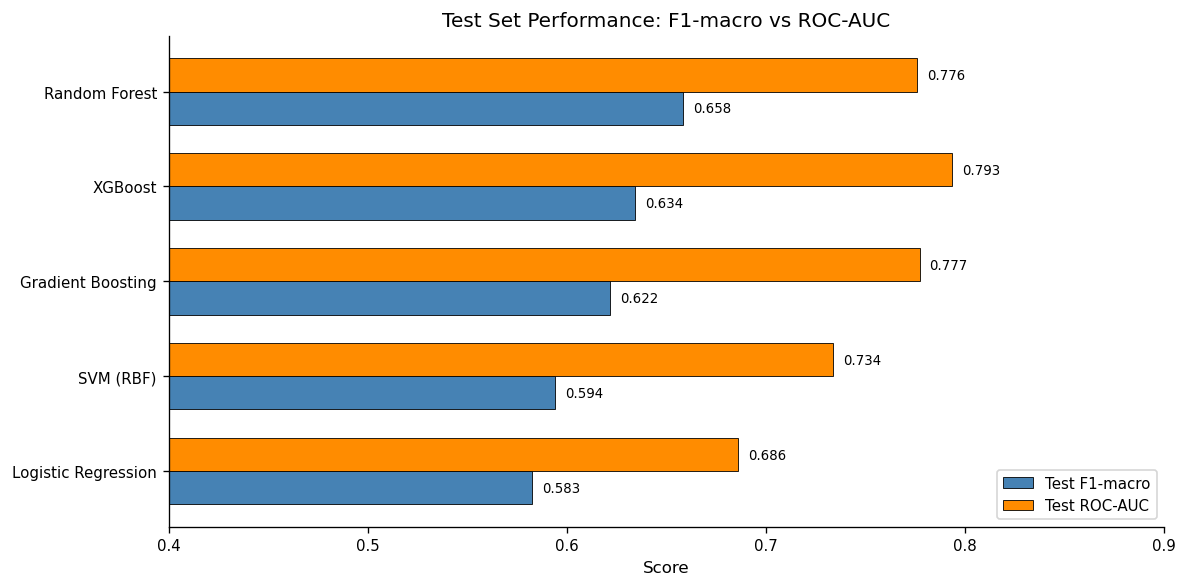

In [44]:
# Grouped bar chart: Test F1-macro and ROC-AUC comparison across all models
fig, ax = plt.subplots(figsize=(10, 5))
models_sorted = test_results.sort_values('Test F1-macro', ascending=True)
x = np.arange(len(models_sorted))
width = 0.35

bars1 = ax.barh(x - width/2, models_sorted['Test F1-macro'], width,
                color='steelblue', edgecolor='black', linewidth=0.5, label='Test F1-macro')
bars2 = ax.barh(x + width/2, models_sorted['Test ROC-AUC'], width,
                color='darkorange', edgecolor='black', linewidth=0.5, label='Test ROC-AUC')

ax.set_yticks(x)
ax.set_yticklabels(models_sorted['Model'])
ax.set_xlabel('Score')
ax.set_title('Test Set Performance: F1-macro vs ROC-AUC')
ax.legend(loc='lower right')
ax.set_xlim(0.4, 0.9)

# Add value labels
for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


The chart makes the ranking clear at a glance. RF leads on test F1 (0.659) while XGBoost
leads on AUC (0.794). Tree-based models as a group (F1 between 0.62 and 0.66) outperform
LR and SVM (both around 0.58-0.59), so non-linear capacity clearly matters for this task.
The fact that F1 and AUC rankings do not perfectly agree is interesting. It suggests
XGBoost produces better probability estimates across all thresholds, but RF makes better
hard predictions at the default 0.5 cutoff.

In [45]:
# Train / CV / Test F1-macro comparison
comp_rows = []
for name, gs in grid_searches.items():
    model = gs.best_estimator_
    yp_tr = model.predict(X_train)
    yp_te = model.predict(X_test)
    comp_rows.append({
        'Model':               name,
        'Train F1-macro':      round(f1_score(y_train, yp_tr, average='macro'), 4),
        'CV F1-macro (best)':  round(gs.best_score_, 4),
        'Test F1-macro':       round(f1_score(y_test,  yp_te, average='macro'), 4),
    })

comp_df = pd.DataFrame(comp_rows)
comp_df


,Model,Train F1-macro,CV F1-macro (best),Test F1-macro
0,Logistic Regression,0.6774,0.6244,0.5826
1,Random Forest,0.9420,0.6887,0.6585
2,Gradient Boosting,0.9530,0.7047,0.6218
3,XGBoost,0.9526,0.7056,0.6344
4,SVM (RBF),0.6968,0.6111,0.5940


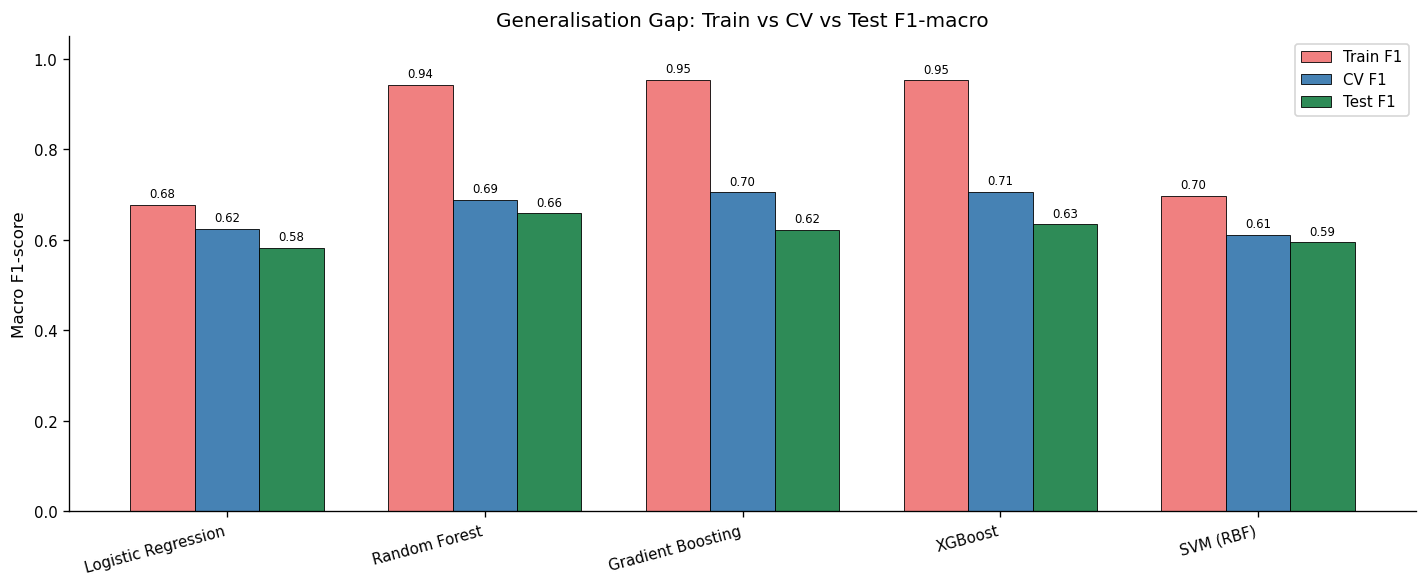

In [46]:
# Grouped bar chart: Train vs CV vs Test F1-macro per model (generalisation gaps)
fig, ax = plt.subplots(figsize=(12, 5))
models = comp_df['Model']
x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, comp_df['Train F1-macro'], width,
               color='lightcoral', edgecolor='black', linewidth=0.5, label='Train F1')
bars2 = ax.bar(x, comp_df['CV F1-macro (best)'], width,
               color='steelblue', edgecolor='black', linewidth=0.5, label='CV F1')
bars3 = ax.bar(x + width, comp_df['Test F1-macro'], width,
               color='seagreen', edgecolor='black', linewidth=0.5, label='Test F1')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Macro F1-score')
ax.set_title('Generalisation Gap: Train vs CV vs Test F1-macro')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# Add value labels on top
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_generalisation_gap.png', dpi=150, bbox_inches='tight')
plt.show()


The grouped bars show the generalisation gap for each model. LR has a modest, steady
decline from train (0.68) to CV (0.62) to test (0.58); it is not memorising anything,
but it is also not capturing much. RF and XGBoost both hit near-perfect training F1
(0.94 and 0.95) but drop to 0.69-0.71 on CV, which is a gap of about 0.25, meaning significant
overfitting on the training folds. The good news is that the CV-to-test gap is small for
both (under 0.07), meaning the regularised hyperparameters found by grid search are doing
their job. SVM looks similar to LR: low capacity, small gap, weak performance overall.
The takeaway is that tree-based models trade higher overfitting risk for a higher ceiling.

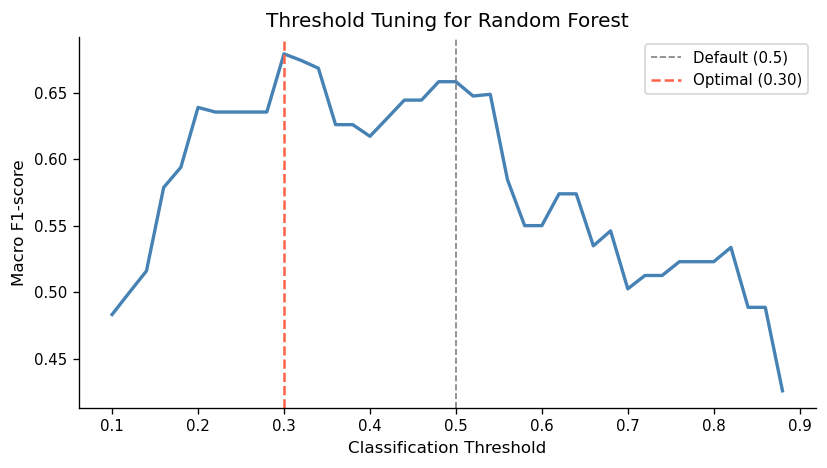

Best model: Random Forest
Default threshold (0.5) F1-macro: 0.6585
Optimal threshold (0.30) F1-macro: 0.6795

Classification report at optimal threshold (0.30):
                  precision    recall  f1-score   support

Not Bottom Q (0)       0.97      0.61      0.75        46
    Bottom Q (1)       0.45      0.94      0.61        16

        accuracy                           0.69        62
       macro avg       0.71      0.77      0.68        62
    weighted avg       0.83      0.69      0.71        62



In [47]:
# Threshold tuning on the best model to improve minority-class recall
best_name = test_results.iloc[0]['Model']
best_model = all_models[best_name]
probs = best_model.predict_proba(X_test)[:, 1]

# Evaluate a range of thresholds
thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores_thresh = []
for t in thresholds:
    yp_t = (probs >= t).astype(int)
    f1_scores_thresh.append(f1_score(y_test, yp_t, average='macro'))

optimal_thresh = thresholds[np.argmax(f1_scores_thresh)]
best_f1_thresh = max(f1_scores_thresh)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores_thresh, color='steelblue', linewidth=2)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='Default (0.5)')
ax.axvline(optimal_thresh, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Optimal ({optimal_thresh:.2f})')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Macro F1-score')
ax.set_title(f'Threshold Tuning for {best_name}')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best model: {best_name}')
print(f'Default threshold (0.5) F1-macro: {f1_score(y_test, best_model.predict(X_test), average="macro"):.4f}')
print(f'Optimal threshold ({optimal_thresh:.2f}) F1-macro: {best_f1_thresh:.4f}')

# Apply optimal threshold
y_pred_opt = (probs >= optimal_thresh).astype(int)
print(f'\nClassification report at optimal threshold ({optimal_thresh:.2f}):')
print(classification_report(y_test, y_pred_opt,
                            target_names=['Not Bottom Q (0)', 'Bottom Q (1)']))


The reason for tuning the threshold is practical. In the OfS context, failing to identify
a struggling provider (a false negative) is much worse than wrongly flagging one that turns
out to be fine (a false positive). A missed provider gets no intervention and its students
keep experiencing poor outcomes. A falsely flagged provider just gets reviewed and the
review concludes it is doing okay. So the default 0.5 threshold, which treats both kinds
of error equally, is not really appropriate here.

The tuning curve peaks at a threshold of 0.30, where macro F1 reaches 0.6795 (up from
0.6585 at 0.5). At this threshold, minority-class recall jumps from 0.62 to 0.94: the
model correctly identifies 15 of the 16 bottom-quartile providers in the test set, missing
only 1. The trade-off is 18 false positives (up from 12), but given the OfS already
conducts routine reviews of all providers, the extra cost of investigating 18 more cases
is small compared to the benefit of catching nearly all at-risk institutions.

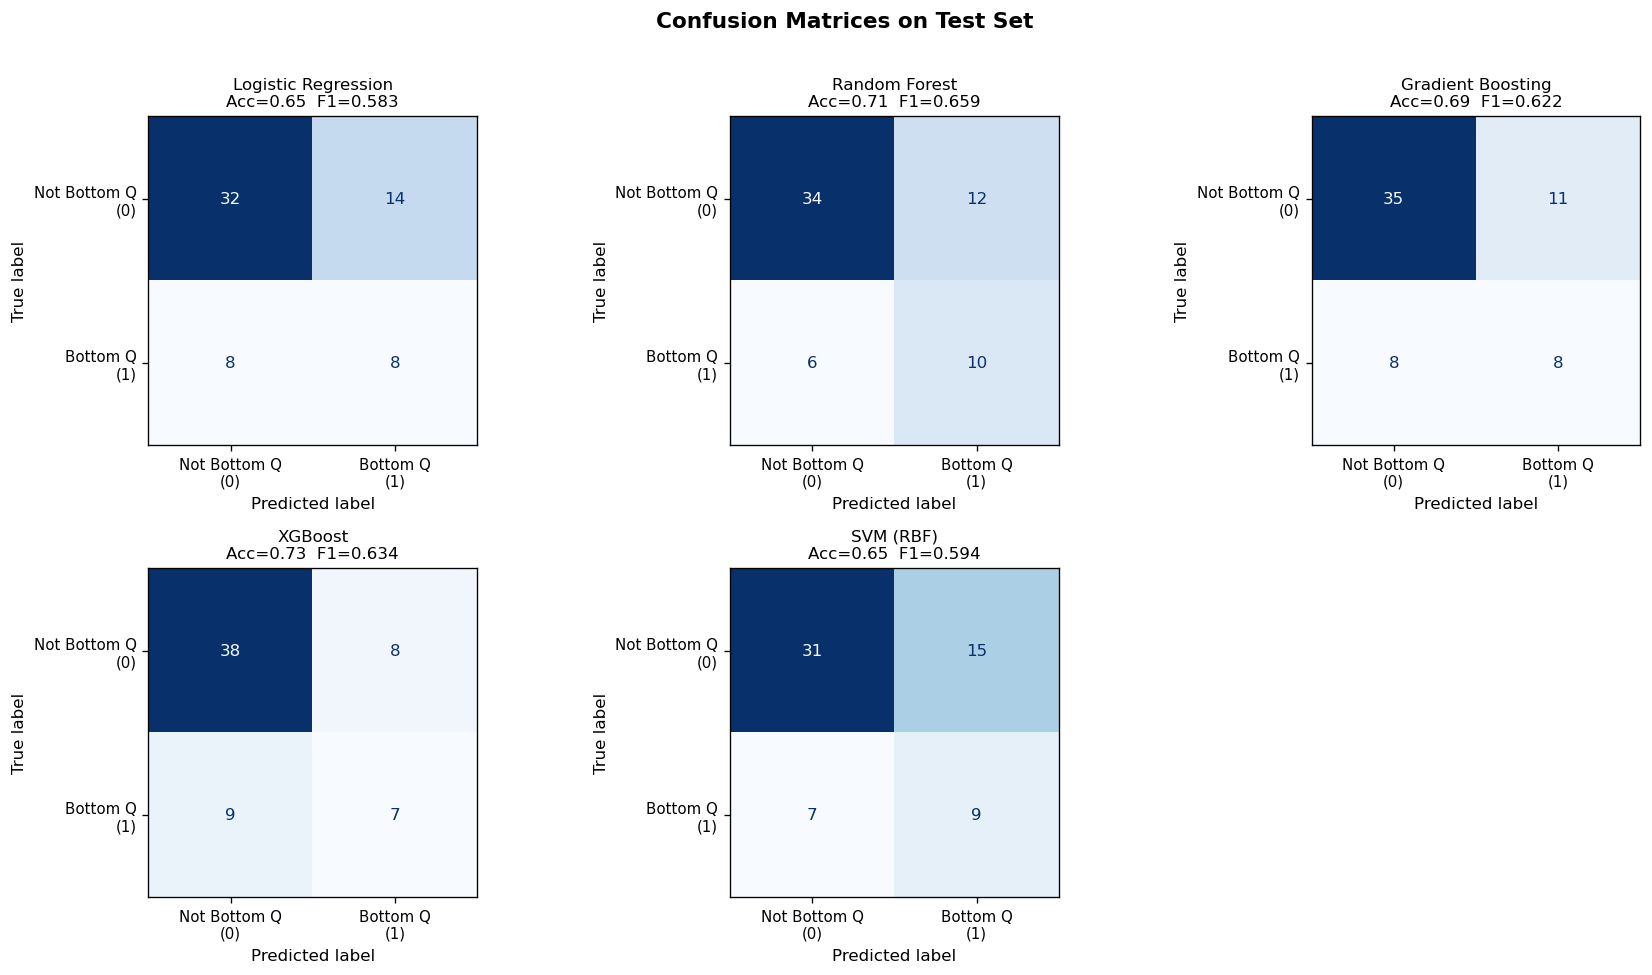

In [48]:
# Confusion matrices for all models (2 rows: 3 + 2)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

model_items = list(all_models.items())
for idx, (name, model) in enumerate(model_items):
    ax = axes_flat[idx]
    yp  = model.predict(X_test)
    cm  = confusion_matrix(y_test, yp)
    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp, average='macro')
    ConfusionMatrixDisplay(
        cm, display_labels=['Not Bottom Q\n(0)', 'Bottom Q\n(1)']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc={acc:.2f}  F1={f1:.3f}', fontsize=10)

# Hide the 6th (empty) subplot
axes_flat[5].set_visible(False)

plt.suptitle('Confusion Matrices on Test Set', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


The confusion matrices show how differently the five models handle errors. RF has the best
balance: TN=34, FP=12, FN=6, TP=10, giving minority-class recall of 0.62 and precision
of 0.45. XGBoost is more conservative with TN=38, FP=8, FN=9, TP=7. It flags fewer
providers but misses 9 of 16 at-risk ones (recall 0.44). LR sits in between with recall
0.50 and precision 0.36.

The main problem across all models is false negatives: bottom-quartile providers that the
model misses. RF misses 6 out of 16. That is what motivated the threshold tuning above.

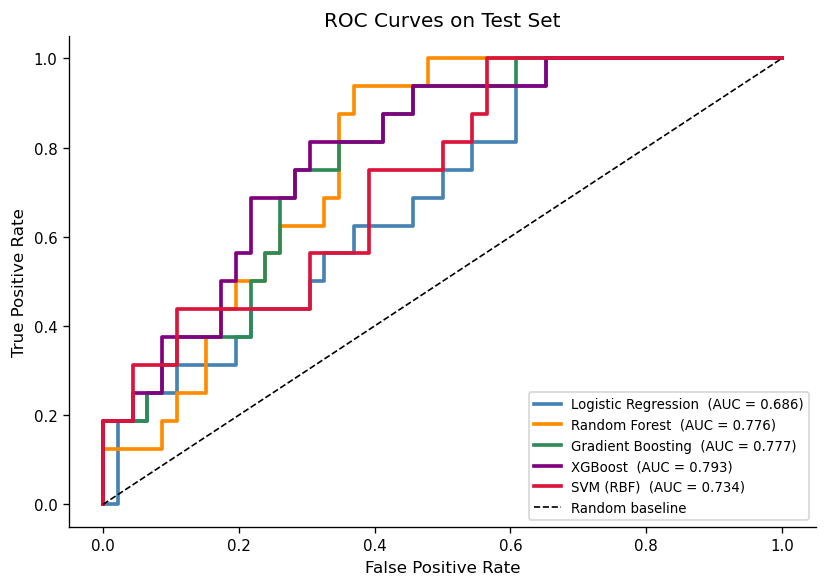

In [49]:
# ROC curves
palette = ['steelblue', 'darkorange', 'seagreen', 'purple', 'crimson']
fig, ax = plt.subplots(figsize=(7, 5))

for (name, model), col in zip(all_models.items(), palette):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=col, linewidth=2.2,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves on Test Set')
ax.legend(loc='lower right', fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


All five ROC curves sit above the diagonal, so every model is learning something real.
XGBoost has the highest AUC at 0.7935, closely followed by GB (0.7772) and RF (0.7758).
SVM (0.7337) and LR (0.6861) trail behind. The tree-based models separate from the
diagonal early on (at low false positive rates), which means they can reliably pick out
the most obvious at-risk providers without too many false alarms. LR stays closer to the
diagonal throughout, reflecting its inability to capture interactions between features.
The gap between XGBoost and RF is tiny (0.018), well within noise for a 62-sample test
set.

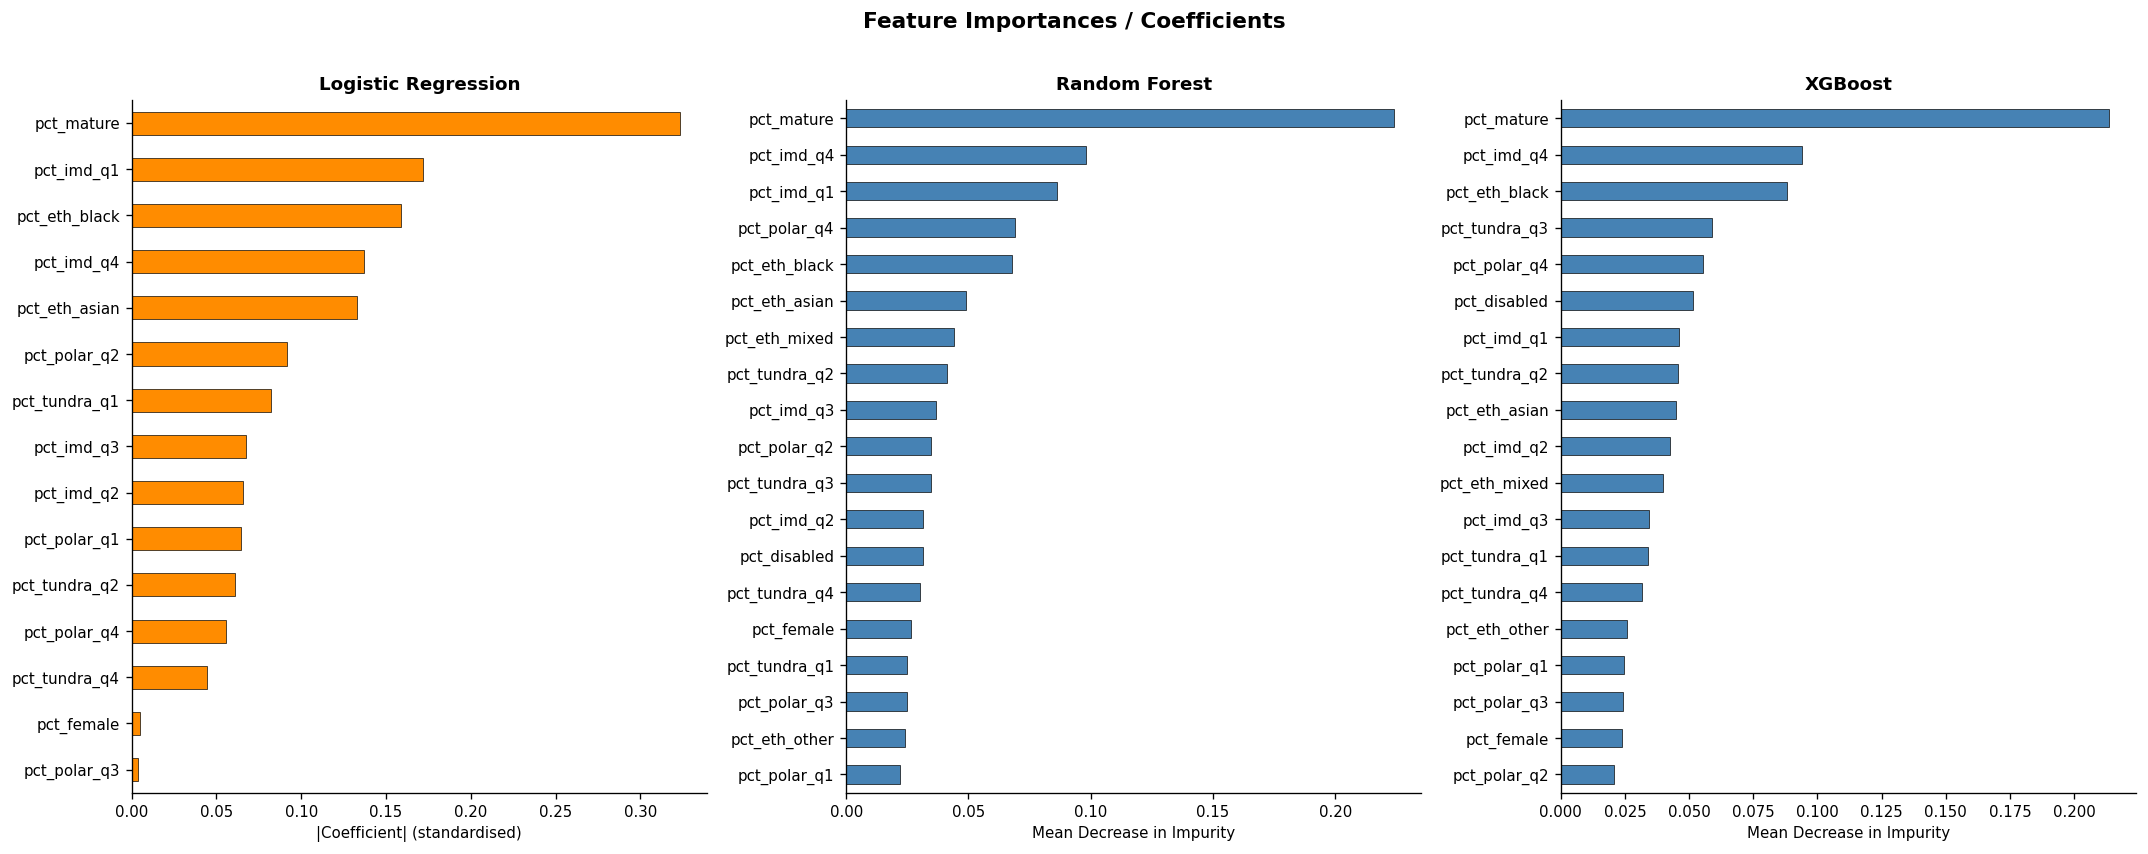

In [50]:
# Feature importances / coefficients for key models
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Select 3 representative models for feature importance plot
importance_models = {}
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    if name in all_models:
        importance_models[name] = all_models[name]

for ax, (name, model) in zip(axes, importance_models.items()):
    clf = model.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        vals  = clf.feature_importances_
        xlabel = 'Mean Decrease in Impurity'
        colour = 'steelblue'
        feat_names = FEATURES
    else:
        vals  = np.abs(clf.coef_[0])
        xlabel = '|Coefficient| (standardised)'
        colour = 'darkorange'
        # If feature selection was applied, get selected feature names
        if 'selector' in model.named_steps:
            sel_mask = model.named_steps['selector'].get_support()
            feat_names = [f for f, m in zip(FEATURES, sel_mask) if m]
        else:
            feat_names = FEATURES
    ser = pd.Series(vals, index=feat_names).sort_values()
    ser.plot(kind='barh', ax=ax, color=colour, edgecolor='black', linewidth=0.4)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Feature Importances / Coefficients', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()


`pct_mature` is the clear winner across all three models. RF gives it 22.4% of total
impurity reduction, more than double the next feature (`pct_imd_q4` at 9.8%). XGBoost
tells the same story (21.3%), and the LR standardised coefficient for `pct_mature` is the
largest at 0.323.

So what does this mean? The single best predictor of whether a provider ends up in the
bottom quartile for completion is how many mature students it has. Providers where over
half the intake is aged 21+ (median 56.2% for bottom-quartile vs 27.2%) tend to be FE
colleges and specialist providers offering part-time or distance learning. The widening
participation literature consistently shows that mature students juggle work, family and
study at the same time, leading to higher dropout rates at the structural level.

The secondary importance of deprivation features (`pct_imd_q1` LR coefficient 0.172,
`pct_imd_q4` RF importance 9.8%) suggests a compounding effect: providers with lots of
mature students *and* high deprivation shares face a double disadvantage. From a policy
angle, the OfS could use these two features as early-warning indicators when reviewing
Access and Participation Plans.

An important caveat: the model cannot tell us *why* these providers have low completion.
It could be student-level factors (financial pressure, caring responsibilities) or
institutional factors (quality of part-time teaching, level of support services).
Disentangling that would need student-level data, which this dataset does not have.

In [51]:
# Detailed classification report for the best test-set model
best_name  = test_results.iloc[0]['Model']
best_model = all_models[best_name]
y_pred_best = best_model.predict(X_test)

print(f'Best model (by Test F1-macro): {best_name}\n')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Not Bottom Q (0)', 'Bottom Q (1)']
))


Best model (by Test F1-macro): Random Forest

                  precision    recall  f1-score   support

Not Bottom Q (0)       0.85      0.74      0.79        46
    Bottom Q (1)       0.45      0.62      0.53        16

        accuracy                           0.71        62
       macro avg       0.65      0.68      0.66        62
    weighted avg       0.75      0.71      0.72        62



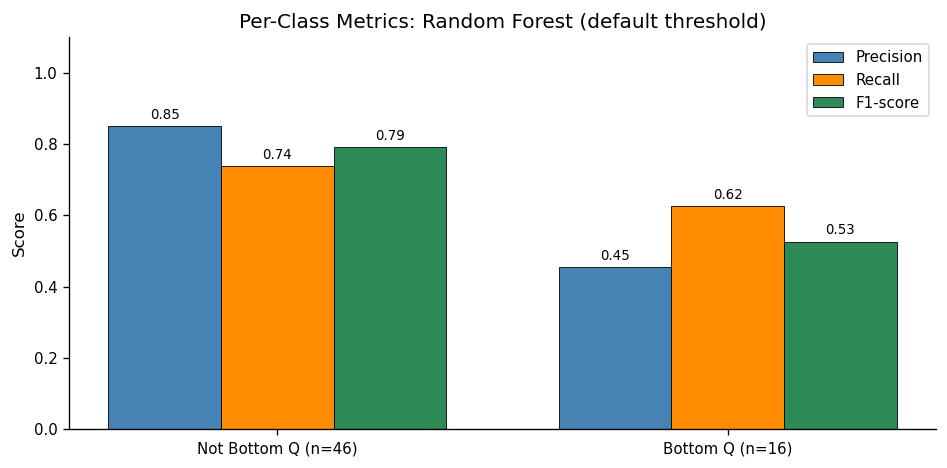

In [52]:
# Per-class precision, recall, F1 bar chart for the best model
from sklearn.metrics import precision_recall_fscore_support
best_name = test_results.iloc[0]['Model']
best_model = all_models[best_name]
y_pred = best_model.predict(X_test)
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, average=None)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
width = 0.25
ax.bar(x - width, prec, width, color='steelblue', edgecolor='black', linewidth=0.5, label='Precision')
ax.bar(x, rec, width, color='darkorange', edgecolor='black', linewidth=0.5, label='Recall')
ax.bar(x + width, f1, width, color='seagreen', edgecolor='black', linewidth=0.5, label='F1-score')

ax.set_xticks(x)
ax.set_xticklabels([f'Not Bottom Q (n={sup[0]})', f'Bottom Q (n={sup[1]})'])
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Metrics: {best_name} (default threshold)')
ax.legend()
ax.set_ylim(0, 1.1)

for i, (p_val, r_val, f_val) in enumerate(zip(prec, rec, f1)):
    ax.text(i - width, p_val + 0.02, f'{p_val:.2f}', ha='center', fontsize=8)
    ax.text(i, r_val + 0.02, f'{r_val:.2f}', ha='center', fontsize=8)
    ax.text(i + width, f_val + 0.02, f'{f_val:.2f}', ha='center', fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


The per-class chart highlights the asymmetry. For the majority class (Not Bottom Q, n=46),
precision, recall and F1 are all above 0.74, so the model handles these providers well. For
the minority class (Bottom Q, n=16), recall (0.62) is higher than precision (0.45), so the
model catches most at-risk providers but also wrongly flags some healthy ones. The minority
F1 of 0.53 vs the majority F1 of 0.79 shows that class imbalance remains a challenge even
with SMOTE, and this gap is exactly what makes threshold tuning a sensible next step.

#### Discussion of Results

Does intake composition predict bottom-quartile completion? The short answer is yes,
to a reasonable degree. The best model (Random Forest) achieves a test AUC of 0.776,
meaning that given one bottom-quartile and one above-quartile provider picked at random,
the model ranks the bottom-quartile one as higher risk 77.6% of the time. With the
threshold lowered to 0.30, it catches 15 of 16 at-risk providers (recall 0.94), though at
the cost of 18 false alarms. That is useful predictive signal, but it is not perfect.

Looking at generalisation, LR has the smallest train-to-test gap (0.68 to 0.58, total drop of
0.10) but the weakest absolute scores. It simply lacks the capacity for this problem.
RF and XGBoost both memorise training data almost perfectly (F1 above 0.94), which looks
alarming, but the regularised hyperparameters keep the CV-to-test gaps under 0.07. That
means grid search did its job in controlling overfitting. One interesting detail: despite
XGBoost leading on CV by 0.017, RF generalised 0.024 better to the test set. This is
probably because RF's bagging is more stable than boosting when the test set is only 62
samples.

At the default 0.5 threshold, RF produces 6 false negatives and 12
false positives (TN=34, TP=10). The 6 missed bottom-quartile providers are the most
concerning from a policy standpoint. XGBoost takes a more conservative approach (TN=38,
FP=8, FN=9, TP=7): fewer false alarms but it misses 9 of 16 at-risk providers (recall
0.44). This illustrates a core trade-off: XGBoost favours precision at the expense of
recall.

In terms of AUC, XGBoost leads at 0.794, then GB (0.777), RF (0.776), SVM (0.734), LR
(0.686). The 0.09 gap between the tree-based group and LR confirms that non-linear
interactions matter. The gap between XGBoost and RF (0.018) is within noise for 62 test
points.

The main thing holding performance back is sample size: 244 training rows with
19 features. The near-perfect training F1 for tree models (0.94-0.95) tells us they have
plenty of capacity; the problem is generalisation, not underfitting. Provider type (Russell
Group, post-1992, FE college) is a big source of variation that intake percentages alone
cannot capture. Including provider-type indicators would likely help, but they were not in
the supplied dataset.

## 6. Conclusion

The aim was to test whether intake composition can predict bottom-quartile completion.
Five classifiers with SMOTE oversampling were trained and evaluated on 306 valid rows from
the OfS dataset.

XGBoost achieved the highest cross-validated F1 (0.7056), but Random Forest generalised
best to the held-out test set (F1=0.659, AUC=0.776). Lowering the classification threshold
to 0.30 pushed test F1 to 0.680 and minority-class recall to 0.94, meaning the model
identified 15 of 16 at-risk providers. So intake composition does carry genuine predictive
signal, though it is far from a complete explanation.

The dominant feature was `pct_mature` (22.4% of RF importance, 29 point median gap between
classes), with IMD deprivation features ranking second (`pct_imd_q1` LR coefficient 0.172,
11 point median gap). One thing that surprised me was how far `pct_polar_q1` fell behind
`pct_imd_q1`, even though both are central to the OfS widening participation framework.
It suggests material deprivation (IMD) matters more for completion outcomes than area-level
participation history (POLAR). That distinction is actually useful for policy, because IMD
data is available at the point of student entry.

There are clear limitations. The model cannot tell apart student-level causes (financial stress, caring
responsibilities) from institutional ones (teaching quality, support services). Provider-type
indicators were not available. And the 62-sample test set limits how precisely any metric
can be estimated.

For future work, the most obvious improvement would be adding provider-type indicators
(Russell Group, post-1992, specialist college) as features. Right now, two institutions
with identical intake profiles but completely different missions and resources get the same
risk score. A provider-type variable would help separate institutional effects from intake
effects.